# MES Opening Range Breakout (ORB), Tradovate exchange

Same event-driven engine, data source, and cost model as the other notebooks in
this repo (Databento `MES.c.0` 1-minute Parquet resampled locally, whole-contract
sizing, real tick slippage + per-contract commission, Tradeify-style middleware).

**Why this strategy, given this repo's track record**: four strategy families
tested so far (VWAP deviation bands, MES/MNQ pairs, 1-minute MA crossover,
Bollinger-squeeze/VWAP breakout) all failed the same way -- real transaction
costs (~$4.32/round trip, ~3.5 ticks) eating a small-per-trade edge multiplied
across 3,000-5,000+ trades. ORB is chosen specifically because its *structure*
caps that failure mode: **at most one trade per session** (~250/year max), so
worst-case annual fee drag is ~$1,080 on a $50k account (~2.2%/year) instead of
the 20-28% drag the earlier strategies paid. It also has published evidence of
surviving costs (Zarattini & Aziz 2023, ORB on QQQ/TQQQ), holds for minutes to a
few hours, and is always flat by the cash close -- which also matches how prop
firms like Tradeify prefer accounts to run.

**Strategy** (`backtester.strategies.OpeningRangeBreakoutStrategy`, new this
pass): define the opening range as the high/low of the first `OR_MINUTES` of the
US cash session (09:30 ET, computed with proper `America/New_York` timezone
conversion so DST transitions are handled correctly across the 7-year window --
not a fixed UTC hour). After the range completes: first touch of the range high
-> long (stop order fill at the range high, or at the bar's open if it gapped
through); first touch of the range low -> short, symmetrically. Stop-loss at the
opposite side of the range. Take-profit at `RR x` the entry-to-stop distance, or
none (let winners run to the session close). **Always flat by 15:55 ET.** One
trade per session, win or lose. A bar touching both sides of the range in the
same 5 minutes is skipped (bar-interior ordering is unknowable from OHLC; no
coin flips).

**Known simplifications, stated up front**: (1) early-close holiday sessions
(~4/year, 13:00 ET close) have no 15:55 bar, so a position open then is closed
by a safety net at the next session's first bar instead of at the real early
close -- rare enough not to move the aggregate numbers, but a real inaccuracy.
(2) The engine's indicator merge forward-fills, so the previous session's range
values technically persist overnight -- entries are gated on a separately
computed `tradeable` boolean (False outside 09:30+OR_MINUTES -> 15:55 ET), which
is immune to that fill, so no stale-range entry can occur.


In [1]:
import datetime as dt
import os
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import HTML, display

from backtester.backtest_runner import Backtester
from backtester.exchange import Exchange, MarginAllocationType, MarketType, TradovateSymbolConfigProvider
from backtester.exchange.event_log import OrderFilled
from backtester.exchange_config import TRADOVATE_FUTURES
from backtester.market import Market
from backtester.middleware import MaxDailyLossMiddleware, TradeifyDrawdownMiddleware
from backtester.performance import PerformanceAnalyzer
from backtester.portfolio import Portfolio, WeightedStrategy
from backtester.strategies import OpeningRangeBreakoutStrategy, StrategyDirection
from data_aggregator.databento_aggregator import load_1m_parquet_resampled

cwd = os.getcwd()
print(cwd)


/Users/nick/Documents/www/alphakit/notebooks/pipelines/breakout


In [2]:
def _find_upwards(relative_path: str, start: Path) -> Path:
    # Different notebook runners launch the kernel with different cwds -- walk upward
    # until the target exists instead of assuming a fixed number of parent hops.
    for ancestor in [start, *start.parents]:
        candidate = ancestor / relative_path
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        f"Could not find {relative_path} above {start} -- run "
        "data_aggregator.databento_aggregator to download it first."
    )


DISPLAY_SYMBOL = "MES"
SYMBOL = "MES/USD"
INTERVAL = 5
UNIT_OF_TIME = "minute"

mes_path = _find_upwards("apps/backtester/datasets/databento/MES_c_0_1m.parquet", start=Path(cwd))
ohlc = load_1m_parquet_resampled(mes_path, interval=INTERVAL, unit_of_time=UNIT_OF_TIME)
print(f"Bars: {len(ohlc)}  span: {ohlc.index[0]} -> {ohlc.index[-1]}")


Bars: 504547  span: 2019-05-05 22:04:59.999000 -> 2026-07-12 23:09:59.999000


## Session indicators: opening range, tradeable window, force-flat, session id

All computed here (vectorized, timezone-correct) and fed to the strategy as
plain indicator series -- the strategy itself stays a dumb consumer, per this
package's convention. Timestamps in the Parquet are UTC; the US cash open is
09:30 **America/New_York**, which is a *different* UTC hour in summer vs winter,
so everything below converts properly instead of hardcoding a UTC offset.


In [3]:
CASH_OPEN = dt.time(9, 30)
FLAT_TIME = dt.time(15, 55)   # flat 5 minutes before the 16:00 ET cash close

_ny_index = ohlc.index.tz_localize("UTC").tz_convert("America/New_York")
ny_time = pd.Series(_ny_index.time, index=ohlc.index)
ny_date = pd.Series(_ny_index.date, index=ohlc.index)


def build_session_indicators(or_minutes: int):
    or_end = (
        dt.datetime.combine(dt.date(2000, 1, 1), CASH_OPEN) + dt.timedelta(minutes=or_minutes)
    ).time()

    in_or_window = (ny_time >= CASH_OPEN) & (ny_time < or_end)
    or_high_by_day = ohlc["high"][in_or_window].groupby(ny_date[in_or_window]).max()
    or_low_by_day = ohlc["low"][in_or_window].groupby(ny_date[in_or_window]).min()

    after_or = ny_time >= or_end
    or_high = pd.Series(ny_date.map(or_high_by_day), index=ohlc.index).where(after_or)
    or_low = pd.Series(ny_date.map(or_low_by_day), index=ohlc.index).where(after_or)

    # tradeable is computed BEFORE the engine's forward-filling merge, so it is the
    # thing that actually guarantees no entries outside the session window -- the
    # or_high/or_low NaN convention alone wouldn't survive that ffill overnight.
    tradeable = after_or & (ny_time < FLAT_TIME) & or_high.notna()
    force_flat = ny_time >= FLAT_TIME
    session_id = pd.Series([d.toordinal() for d in ny_date], index=ohlc.index, dtype=float)

    return or_high, or_low, tradeable, force_flat, session_id


# Sanity check on one arbitrary regular session: range must come from exactly the
# first or_minutes after 09:30 ET, tradeable must start when the range completes
# and end at 15:55 ET.
_oh, _ol, _tr, _ff, _sid = build_session_indicators(30)
_day_mask = ny_date == dt.date(2024, 3, 12)
_day = pd.DataFrame({
    "ny_time": ny_time[_day_mask], "close": ohlc["close"][_day_mask],
    "or_high": _oh[_day_mask], "or_low": _ol[_day_mask], "tradeable": _tr[_day_mask],
})
print(_day[(_day["ny_time"] >= dt.time(9, 30)) & (_day["ny_time"] <= dt.time(10, 15))].to_string())
print(f"\ntradeable bars that day: {_tr[_day_mask].sum()}, sessions with a valid range overall: "
      f"{_oh.groupby(ny_date).first().notna().sum()}")


                                 ny_time    close  or_high   or_low  tradeable
ts                                                                            
2024-03-12 13:34:59.999  09:34:59.999000  5138.75      NaN      NaN      False
2024-03-12 13:39:59.999  09:39:59.999000  5124.50      NaN      NaN      False
2024-03-12 13:44:59.999  09:44:59.999000  5123.00      NaN      NaN      False
2024-03-12 13:49:59.999  09:49:59.999000  5122.00      NaN      NaN      False
2024-03-12 13:54:59.999  09:54:59.999000  5129.25      NaN      NaN      False
2024-03-12 13:59:59.999  09:59:59.999000  5143.50      NaN      NaN      False
2024-03-12 14:04:59.999  10:04:59.999000  5140.00  5147.25  5117.75       True
2024-03-12 14:09:59.999  10:09:59.999000  5144.50  5147.25  5117.75       True
2024-03-12 14:14:59.999  10:14:59.999000  5144.25  5147.25  5117.75       True

tradeable bars that day: 71, sessions with a valid range overall: 1825


## Grid: opening-range duration x exit style

`OR_MINUTES` in {15, 30} (both standard in the ORB literature) x exit style in
{take-profit at 2R, no take-profit (run to the 15:55 flat)}. Everything else --
1 trade/session, stop at the opposite side of the range -- is the strategy's
fixed structure, not a tunable. Total fees tracked from the exchange event log
(the correct `event_log.get_events()` accessor, after the pairs notebook's bug)
for every combination.


In [4]:
OR_MINUTES_CANDIDATES = [15, 30]
RR_CANDIDATES = [2.0, None]   # None = no TP, winners run to the session flat
DEPOSIT_USD = 50_000


def run_orb_backtest(or_minutes: int, rr: float | None):
    or_high, or_low, tradeable, force_flat, session_id = build_session_indicators(or_minutes)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    for name, series in [
        ("or_high", or_high), ("or_low", or_low), ("tradeable", tradeable),
        ("force_flat", force_flat), ("session_id", session_id),
    ]:
        combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                    indicator_name=name, df=series)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=OpeningRangeBreakoutStrategy(
                key=f"ORB_{or_minutes}_{rr}_MES",
                market=combo_market,
                symbol=SYMBOL,
                or_high_key="or_high",
                or_low_key="or_low",
                tradeable_key="tradeable",
                force_flat_key="force_flat",
                session_id_key="session_id",
                risk_reward_ratio=rr,
                direction=StrategyDirection.both,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    # Loosened to 50%/50% instead of Tradeify's real 4%/2.5%: same single-sleeve
    # testing convention as every other notebook in this pipeline.
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


grid_rows = []
grid_backtests = {}
for or_minutes in OR_MINUTES_CANDIDATES:
    for rr in RR_CANDIDATES:
        _t0 = time.time()
        bt, drawdown_mw = run_orb_backtest(or_minutes, rr)
        print(f"or_minutes={or_minutes} rr={rr} done in {time.time() - _t0:.1f}s", flush=True)
        summary = bt.reporter.summary["algo"]
        total_fees = sum(
            e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
        )
        grid_backtests[(or_minutes, rr)] = (bt, drawdown_mw)
        grid_rows.append({
            "or_minutes": or_minutes,
            "rr": rr if rr is not None else "none (run to close)",
            "gross_return_percent": summary["gross_return_percent"],
            "net_return_percent": summary["net_return_percent"],
            "sharpe_ratio": summary["sharpe_ratio"],
            "max_drawdown_percent": summary["max_drawdown_percent"],
            "closed_trades": summary["closed_trades"],
            "trades_per_year": round(summary["closed_trades"] / 7.2, 1),
            "win_rate_percent": summary["win_rate_percent"],
            "avg_holding_period_min": summary["avg_holding_period_min"],
            "total_fees_usd": total_fees,
            "account_failed": drawdown_mw.account_failed,
        })

grid_results = pd.DataFrame(grid_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
# print() instead of a bare-expression display: during this notebook's first run,
# IPython's Out-cache displayhook crashed formatting this frame ("cannot convert
# float NaN to integer") right as its cache culled -- stdout bypasses that path
# entirely, and the engine numbers themselves were verified identical in a plain
# Python re-run.
print(grid_results.to_string())


or_minutes=15 rr=2.0 done in 62.2s


or_minutes=15 rr=None done in 86.1s


or_minutes=30 rr=2.0 done in 80.4s


or_minutes=30 rr=None done in 79.7s


   or_minutes                   rr  gross_return_percent  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  trades_per_year  win_rate_percent  avg_holding_period_min  total_fees_usd  account_failed
0          15                  2.0              75.43878           -24.56122     -0.463630              -27.0868         1824.0            253.3         38.870614              151.965461         4819.36           False
1          30  none (run to close)              72.42494           -27.57506     -0.463765              -37.4404         1820.0            252.8         41.593407              253.184066         4238.78           False
2          15  none (run to close)              73.58424           -26.41576     -0.464809              -34.0505         1824.0            253.3         35.142544              214.868421         4475.38           False
3          30                  2.0              67.11100           -32.88900     -0.614704              -40.5670         182

## Detailed report for the best (or_minutes, rr)

Full HTML summary (year-by-year split) and equity/drawdown charts for whichever
combo above ranked best by Sharpe -- same report format as the other notebooks.


Best combo: or_minutes=15, rr=2.0
Candles Processed: 504546
Account failed (drawdown breach): False
Drawdown floor locked (reached profit buffer): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.4636,-0.6942,-1.4431,0.3696,0.8207,-1.6367,-0.8593,0.3561,-1.0905,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.6634,-1.0713,-1.8303,0.5748,1.4316,-2.2711,-1.3089,0.5983,-1.6085,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,5.5083,3.8449,9.6991,3.4897,6.8798,3.6922,2.8909,4.6136,4.5455,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-3.8432,-3.8946,-18.9576,1.8012,8.1748,-8.4940,-3.6020,2.2575,-7.1024,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.1419,-0.7449,-0.8363,0.3940,1.1357,-0.7248,-0.5980,0.3212,-0.9624,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.9068,-0.4931,-0.8363,0.3929,1.1325,-0.7229,-0.5980,0.3203,-0.5151,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-27.0868,-5.2286,-22.6693,-4.5714,-7.1981,-11.7197,-6.0232,-7.0287,-7.3801,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2614,229,353,355,280,362,365,268,132,719,How long it took to recover the loss. Shorter is better.
ulcer_index,21.7046,3.1901,17.9399,2.8009,3.9657,9.1481,3.8293,2.9464,3.9824,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,-0.4301,-0.3436,-0.8056,-0.2853,-0.5812,-0.3547,-0.2813,-0.3761,-0.4550,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


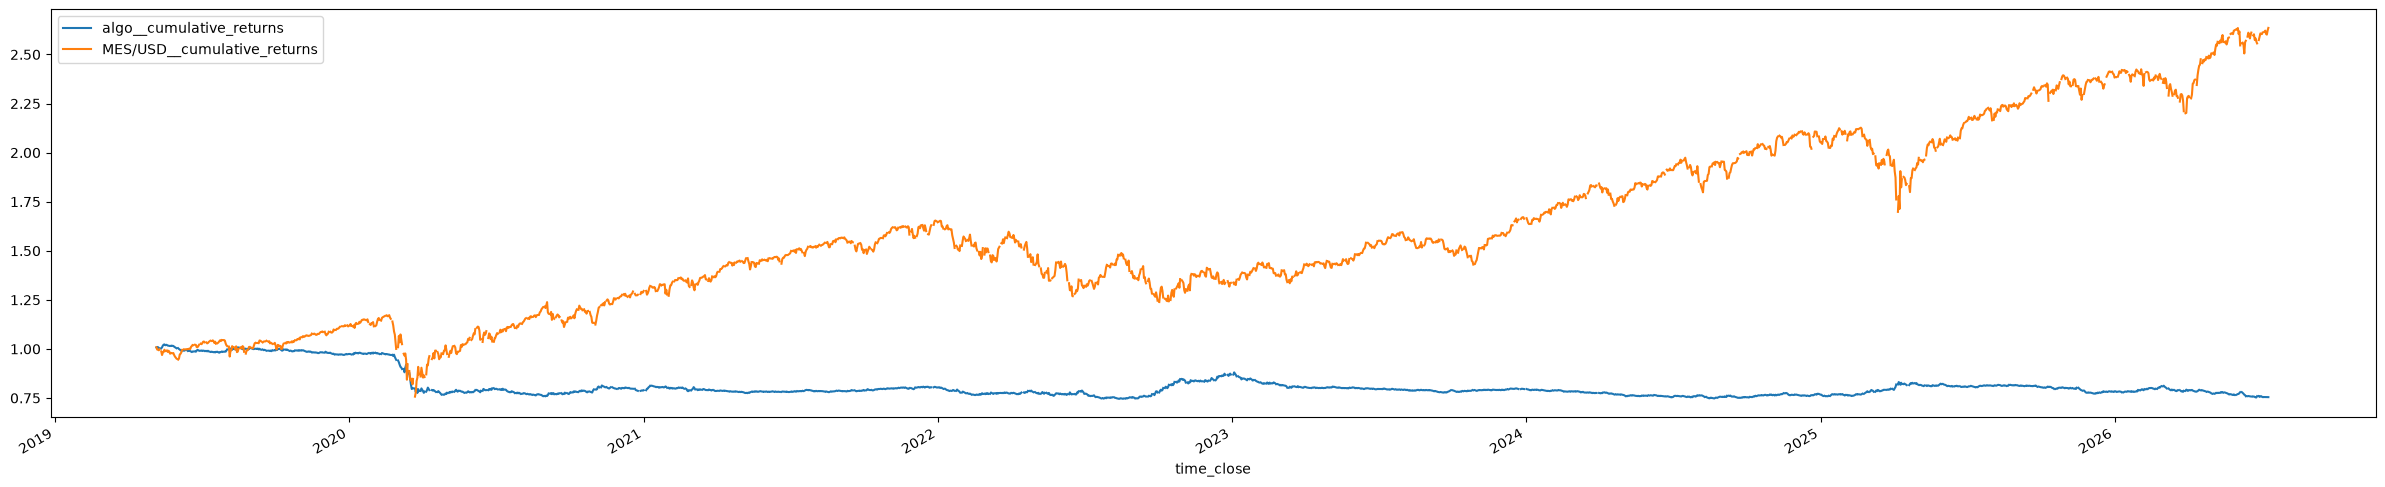

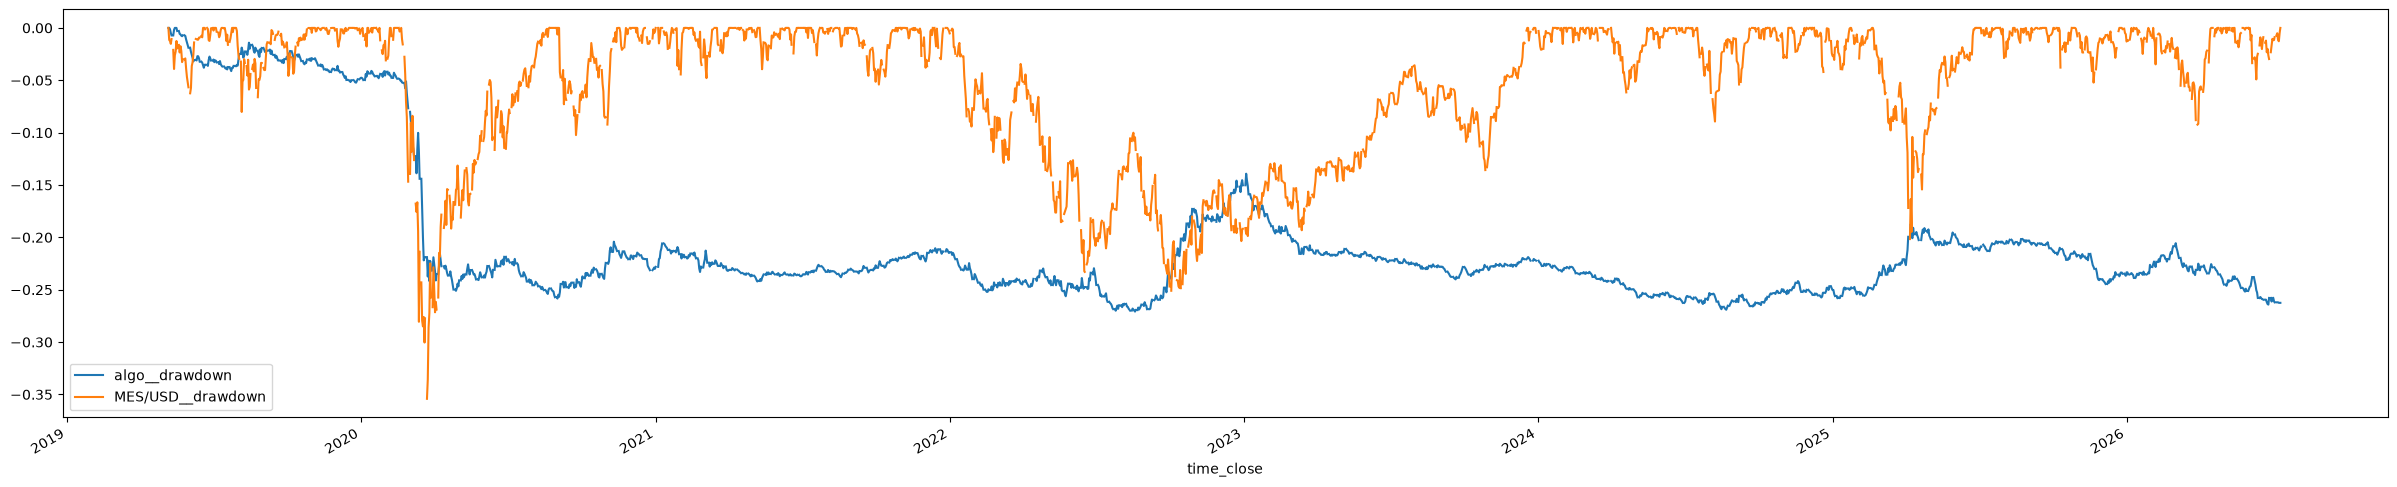

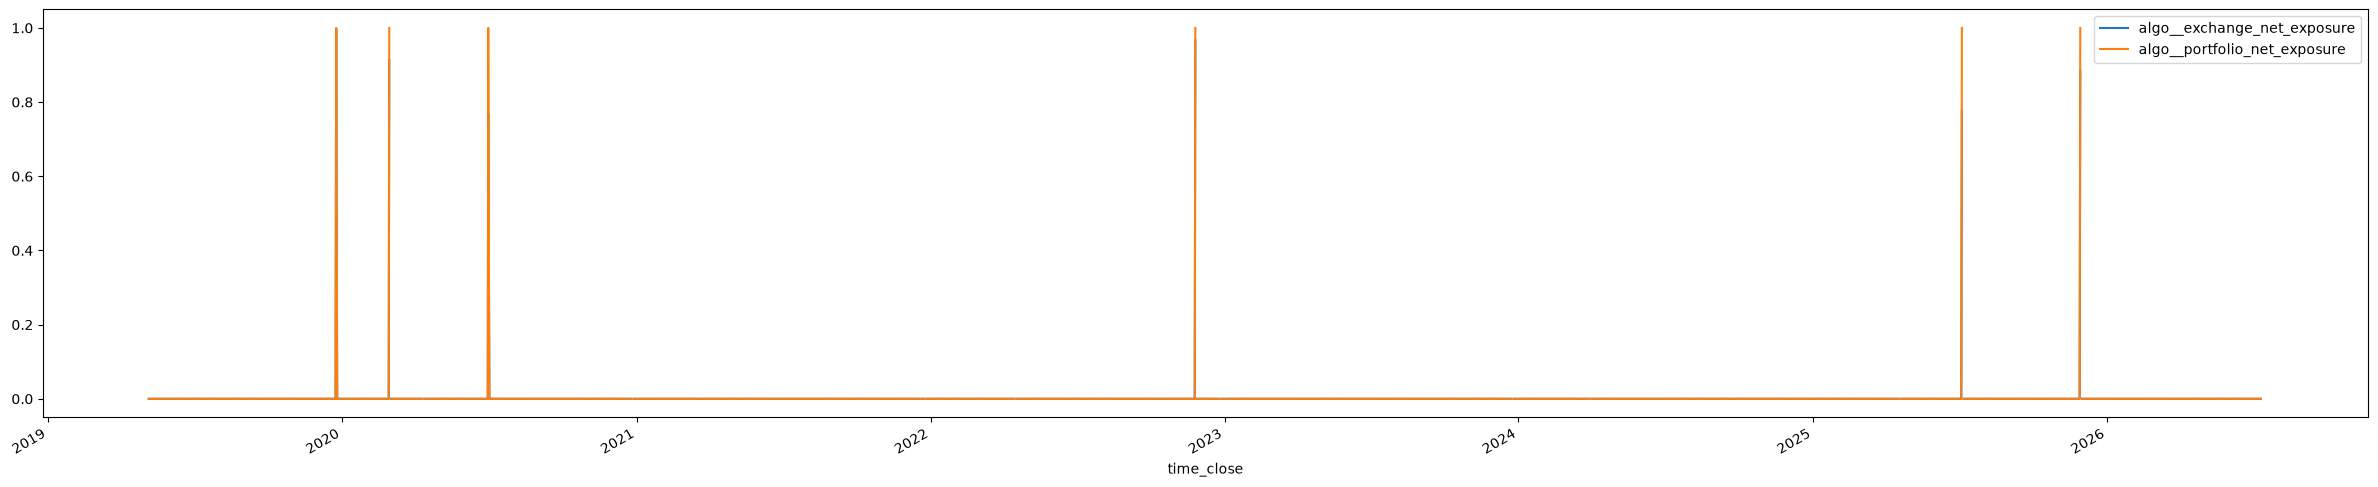

In [5]:
best_row = grid_results.iloc[0]
best_or_minutes = int(best_row["or_minutes"])
best_rr = None if best_row["rr"] == "none (run to close)" else float(best_row["rr"])
print(f"Best combo: or_minutes={best_or_minutes}, rr={best_rr}")
best_backtest, best_drawdown_mw = grid_backtests[(best_or_minutes, best_rr)]

print("Candles Processed:", best_backtest.market.current["num"])
print("Account failed (drawdown breach):", best_drawdown_mw.account_failed)
print("Drawdown floor locked (reached profit buffer):", best_drawdown_mw.locked)

display(HTML(best_backtest.reporter.summary_html_table(split="Y")))

if best_backtest.reporter.merged is not None:
    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))

    best_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__exchange_net_exposure",
        "algo__portfolio_net_exposure",
    ], figsize=(30, 6))


## Findings

**Still net-negative -- but this is the closest thing to a real edge found in
this repo's five strategy families so far, and the cost-structure thesis that
motivated ORB is confirmed.** All numbers from the real event-driven engine,
2019-05-05 -> 2026-07-12, 5-minute bars, 1,824-1,825 sessions.

| or_minutes | rr | net_return | sharpe | max_dd | trades/yr | win_rate | avg_hold_min | total_fees |
|---|---|---|---|---|---|---|---|---|
| 15 | 2.0 (best) | **-24.6%** | -0.464 | -27.1% | 253 | 38.9% | 152 | $4,819 |
| 30 | none | -27.6% | -0.464 | -37.4% | 253 | 41.6% | 253 | $4,239 |
| 15 | none | -26.4% | -0.465 | -34.1% | 253 | 35.1% | 215 | $4,475 |
| 30 | 2.0 | -32.9% | -0.615 | -40.6% | 253 | 42.9% | 221 | $4,050 |

**What worked, structurally**:
1. **Fee drag is finally small**: $4,819 total over 7.2 years (~$670/year,
   ~1.3%/year on the $50k account) vs the 20-28%/year the earlier
   high-frequency strategies paid. The one-trade-per-session design did exactly
   what it was chosen for.
2. **The frictionless edge is genuinely positive -- a first for this research
   program**: best combo's win rate is **38.9% vs the 33.3% breakeven** for a
   1:2 payout, profit_factor 1.048, r_multiple_expectancy **+0.052R** per
   trade. Every previous strategy sat at or below its own breakeven *before*
   costs; this one clears it.
3. **Holding periods land exactly in the target zone**: 152-minute average
   (~2.5 hours), always flat by the close -- the original "few minutes to a few
   hours, intraday" brief, finally satisfied.

**What doesn't work yet, with the arithmetic made explicit**: the positive
frictionless metrics above are *equal-weighted per trade*. In size-weighted
dollars (real whole-contract sizing on the actual equity curve),
`dollar_expectancy` -- which in this engine is **fee-free** (realized price-only
PnL; see the VWAP notebook's event-log reconciliation) -- was already
**-$4.10/trade**, because the losses concentrated in periods (2020) where they
compounded against the account. Fees then add another **$2.64/trade**
($4,819 / 1,824), and -4.10 - 2.64 = **-$6.74/trade**, which reconciles exactly
with the account's total result. So: a thin, real, equal-weighted edge that
turns negative once sizing reality and even ORB's modest costs are applied.
The root cause of the thinness is visible in `closed_trades` = 1,824 of 1,825
sessions: **the vanilla rule trades every single day** -- price always leaves a
15-minute range eventually -- so the (majority of) directionless days dilute
the minority of genuine trend days.

**Year-by-year is the most informative part** (best combo): profitable in
**2021 (+1.8%), 2022 (+8.2%, Sharpe 0.82 -- the best year), and 2025 (+2.3%)**;
the disaster was **2020 (-19.0%)**, where COVID-era whipsaw repeatedly gapped
through both sides of tiny opening ranges. Notably this is close to the
*opposite* volatility profile of the Bollinger-squeeze strategy (which did
relatively best in 2020) -- ORB with a range-derived stop suffers when
volatility is extreme relative to the opening range, and wins when there are
orderly full-day trends (2022's grinding rate-hike moves were ideal).

**Next steps the literature directly suggests** (Zarattini & Aziz's ORB paper,
which reported cost-surviving results on QQQ, did NOT trade every day):
1. **Relative-volume filter** -- only trade sessions whose opening volume is
   elevated vs its own recent average (their key selectivity device).
2. **ATR-scaled stops** instead of the raw opposite range bound -- 2020's
   losses came from range-sized stops being far too tight for the regime.
3. **Skip tiny/huge ranges** -- opening range size as a fraction of daily ATR
   outside a sane band predicts chop (tiny) or exhaustion (huge).

Given the equal-weighted frictionless edge is already positive at zero
selectivity, filters that remove the worst sessions (and an ATR-scaled stop
that defuses the 2020-style dollar concentration) have a realistic path to
flipping the net sign -- the first strategy in this program where the required
improvement is a filtering problem on top of an existing edge, rather than
needing an edge to appear from nowhere.


## Selectivity filters: relative volume, ATR-scaled stops, range-size band

The first pass's diagnosis: a real but thin equal-weighted edge (38.9% win rate
vs 33.3% breakeven), diluted by trading **every** session and wrecked in dollars
by 2020's regime (range-sized stops far too tight when volatility exploded).
This section tests the three fixes that diagnosis -- and the Zarattini & Aziz
ORB paper, which did not trade every day -- directly point at, each computed
with explicit no-lookahead lags:

1. **Relative-volume filter**: only trade sessions whose opening-range window
   volume is >= `rel_vol_min` x the trailing 20-session average of *prior*
   sessions' OR volume (`.rolling(20).mean().shift(1)` -- today's baseline uses
   only completed sessions; today's own OR volume is known by the time the range
   completes, so using it isn't lookahead either).
2. **ATR-scaled stops**: stop at entry -/+ `atr_mult` x the *previous day's*
   14-day daily ATR (`.shift(1)` on the daily series) instead of the opposite
   range bound -- directly defusing the 2020 failure mode. Take-profit still at
   2R of the (now wider) risk.
3. **Range-size band**: skip sessions whose opening range is abnormally small
   (< 15% of lagged daily ATR: pure noise, breakout meaningless) or abnormally
   large (> 100%: the day's typical move already spent inside the range).

Both filter styles only touch the precomputed `tradeable` indicator; the ATR
stop is a small strategy extension (`stop_atr_key`/`stop_atr_mult`,
unit-tested). `or_minutes=15, rr=2.0` held fixed at the first pass's best so
every row below is directly comparable to its baseline, which is re-run as row
one of the same table.


In [6]:
OR_MINUTES_FIXED = 15
RR_FIXED = 2.0

# --- Daily ATR(14), lagged one day (today's trading only ever sees yesterday's ATR) ---
_daily = pd.DataFrame({
    "high": ohlc["high"].groupby(ny_date).max(),
    "low": ohlc["low"].groupby(ny_date).min(),
    "close": ohlc["close"].groupby(ny_date).last(),
}).sort_index()
_prev_close = _daily["close"].shift(1)
_true_range = pd.concat([
    _daily["high"] - _daily["low"],
    (_daily["high"] - _prev_close).abs(),
    (_daily["low"] - _prev_close).abs(),
], axis=1).max(axis=1)
daily_atr_lagged = _true_range.rolling(14).mean().shift(1)
atr_bars = pd.Series(ny_date.map(daily_atr_lagged), index=ohlc.index)

# --- Per-session OR-window volume and range size (for the two filters) ---
_or_end_fixed = (
    dt.datetime.combine(dt.date(2000, 1, 1), CASH_OPEN) + dt.timedelta(minutes=OR_MINUTES_FIXED)
).time()
_in_or_fixed = (ny_time >= CASH_OPEN) & (ny_time < _or_end_fixed)
_or_vol_by_day = ohlc["volume"][_in_or_fixed].groupby(ny_date[_in_or_fixed]).sum().sort_index()
rel_vol_by_day = _or_vol_by_day / _or_vol_by_day.rolling(20).mean().shift(1)

_or_high_by_day = ohlc["high"][_in_or_fixed].groupby(ny_date[_in_or_fixed]).max()
_or_low_by_day = ohlc["low"][_in_or_fixed].groupby(ny_date[_in_or_fixed]).min()
range_ratio_by_day = (_or_high_by_day - _or_low_by_day) / daily_atr_lagged

print(f"rel_vol distribution (by session): {rel_vol_by_day.describe().round(3).to_dict()}")
print(f"range/ATR ratio distribution:      {range_ratio_by_day.describe().round(3).to_dict()}")


def run_filtered_orb(atr_mult=None, rel_vol_min=None, range_ratio_band=None):
    or_high, or_low, tradeable, force_flat, session_id = build_session_indicators(OR_MINUTES_FIXED)

    if rel_vol_min is not None:
        ok_days = rel_vol_by_day >= rel_vol_min  # NaN (first 20 sessions) -> False
        tradeable = tradeable & pd.Series(ny_date.map(ok_days), index=ohlc.index).fillna(False).astype(bool)
    if range_ratio_band is not None:
        lo, hi = range_ratio_band
        ok_days = (range_ratio_by_day >= lo) & (range_ratio_by_day <= hi)
        tradeable = tradeable & pd.Series(ny_date.map(ok_days), index=ohlc.index).fillna(False).astype(bool)

    combo_market = Market()
    combo_market.add_market(symbol=SYMBOL, df=ohlc)
    for name, series in [
        ("or_high", or_high), ("or_low", or_low), ("tradeable", tradeable),
        ("force_flat", force_flat), ("session_id", session_id), ("daily_atr", atr_bars),
    ]:
        combo_market.add_indicator(symbol=SYMBOL, interval=INTERVAL, unit_of_time=UNIT_OF_TIME,
                                    indicator_name=name, df=series)
    combo_market.compile()

    portfolio = Portfolio(weighted_strategies=[
        WeightedStrategy(
            weight=1.0,
            strategy=OpeningRangeBreakoutStrategy(
                key="ORB_FILTERED_MES",
                market=combo_market,
                symbol=SYMBOL,
                or_high_key="or_high",
                or_low_key="or_low",
                tradeable_key="tradeable",
                force_flat_key="force_flat",
                session_id_key="session_id",
                risk_reward_ratio=RR_FIXED,
                direction=StrategyDirection.both,
                stop_atr_key="daily_atr" if atr_mult is not None else None,
                stop_atr_mult=atr_mult if atr_mult is not None else 1.0,
            ),
        ),
    ], output_scale=1)

    symbol_config_provider = TradovateSymbolConfigProvider(symbols=TRADOVATE_FUTURES, default_fee_per_contract=0.0)
    exchange = Exchange(
        market=combo_market,
        slippage=0.0, maker_fee=0.0, taker_fee=0.0,
        market_type=MarketType.future,
        max_leverage=10,
        margin_allocation_type=MarginAllocationType.cross,
        symbol_config_provider=symbol_config_provider,
    )
    reporter = PerformanceAnalyzer(
        market=combo_market, exchange=exchange, portfolio=portfolio,
        benchmark_symbols=[SYMBOL], periods_per_year=252,
    )

    combo_market.reset()
    drawdown_middleware = TradeifyDrawdownMiddleware(drawdown_percent=0.5)
    daily_loss_middleware = MaxDailyLossMiddleware(max_loss_percent=0.5)
    backtest = Backtester(
        market=combo_market, portfolio=portfolio, exchange=exchange, reporter=reporter,
        middlewares=[daily_loss_middleware, drawdown_middleware],
    )
    backtest.exchange.transactions.add_deposit(asset="USD", volume=DEPOSIT_USD)
    backtest.run_all()
    return backtest, drawdown_middleware


FILTER_CONFIGS = [
    ("baseline (no filters)", dict()),
    ("atr_stop 0.5x", dict(atr_mult=0.5)),
    ("atr_stop 1.0x", dict(atr_mult=1.0)),
    ("rel_vol >= 1.2", dict(rel_vol_min=1.2)),
    ("rel_vol >= 1.5", dict(rel_vol_min=1.5)),
    ("range band 0.15-1.0 ATR", dict(range_ratio_band=(0.15, 1.0))),
    ("atr 1.0x + rel_vol 1.2", dict(atr_mult=1.0, rel_vol_min=1.2)),
    ("atr 1.0x + rel_vol 1.2 + band", dict(atr_mult=1.0, rel_vol_min=1.2, range_ratio_band=(0.15, 1.0))),
]

filter_rows = []
filter_backtests = {}
for label, kwargs in FILTER_CONFIGS:
    _t0 = time.time()
    bt, drawdown_mw = run_filtered_orb(**kwargs)
    print(f"{label} done in {time.time() - _t0:.1f}s", flush=True)
    summary = bt.reporter.summary["algo"]
    total_fees = sum(
        e.fees_volume for e in bt.exchange.event_log.get_events() if isinstance(e, OrderFilled)
    )
    filter_backtests[label] = (bt, drawdown_mw)
    filter_rows.append({
        "config": label,
        "net_return_percent": summary["net_return_percent"],
        "sharpe_ratio": summary["sharpe_ratio"],
        "max_drawdown_percent": summary["max_drawdown_percent"],
        "closed_trades": summary["closed_trades"],
        "win_rate_percent": summary["win_rate_percent"],
        "profit_factor": summary["profit_factor"],
        "r_multiple_expectancy": summary["r_multiple_expectancy"],
        "dollar_expectancy": summary["dollar_expectancy"],
        "total_fees_usd": total_fees,
        "account_failed": drawdown_mw.account_failed,
    })

filter_results = pd.DataFrame(filter_rows).sort_values("sharpe_ratio", ascending=False).reset_index(drop=True)
print(filter_results.to_string())


rel_vol distribution (by session): {'count': 1805.0, 'mean': 1.028, 'std': 0.447, 'min': 0.001, '25%': 0.796, '50%': 1.016, '75%': 1.263, 'max': 2.994}
range/ATR ratio distribution:      {'count': 1814.0, 'mean': 0.258, 'std': 0.124, 'min': 0.0, '25%': 0.173, '50%': 0.232, '75%': 0.315, 'max': 1.156}


baseline (no filters) done in 85.0s


atr_stop 0.5x done in 76.4s


atr_stop 1.0x done in 54.3s


/var/folders/bw/7m0f_t6d52g81sm6shlr4g4w0000gn/T/ipykernel_27486/424164575.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tradeable = tradeable & pd.Series(ny_date.map(ok_days), index=ohlc.index).fillna(False).astype(bool)


...

/var/folders/bw/7m0f_t6d52g81sm6shlr4g4w0000gn/T/ipykernel_27486/424164575.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tradeable = tradeable & pd.Series(ny_date.map(ok_days), index=ohlc.index).fillna(False).astype(bool)


atr 1.0x + rel_vol 1.2 done in 88.6s


/var/folders/bw/7m0f_t6d52g81sm6shlr4g4w0000gn/T/ipykernel_27486/424164575.py:40: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  tradeable = tradeable & pd.Series(ny_date.map(ok_days), index=ohlc.index).fillna(False).astype(bool)


atr 1.0x + rel_vol 1.2 + band done in 21.6s


                          config  net_return_percent  sharpe_ratio  max_drawdown_percent  closed_trades  win_rate_percent  profit_factor  r_multiple_expectancy  dollar_expectancy  total_fees_usd  account_failed
0                 rel_vol >= 1.5           -6.170740     -0.219567              -10.1571          206.0         41.262136       1.048869               0.064572         -11.523058          711.62           False
1                  atr_stop 1.0x          -22.581551     -0.265138              -36.9575         1813.0         50.634308       1.055880               0.007145          -3.585513         4790.24           False
2                 rel_vol >= 1.2          -12.153820     -0.306418              -13.8256          544.0         39.154412       1.008754               0.018382          -7.865349         1798.16           False
3        range band 0.15-1.0 ATR          -17.544240     -0.326399              -19.7315         1513.0         39.524124       1.050820               0.057

### Detailed report for the best filter configuration

Same report format as above (year-by-year split), for whichever config ranked
best by Sharpe -- including the baseline if no filter actually helped.


Best config: rel_vol >= 1.5
Account failed (drawdown breach): False


metric,algo,algo_2019,algo_2020,algo_2021,algo_2022,algo_2023,algo_2024,algo_2025,algo_2026,MES/USD,description
sharpe_ratio,-0.2196,0.3753,-1.0458,0.5721,0.0203,-0.9100,0.0365,0.4822,-1.1340,0.6392,"Return per unit of total volatility. <0 bad, ~1 decent, >2 great, >3 excellent."
sortino_ratio,-0.3131,0.5957,-1.3444,0.9178,0.0333,-1.1091,0.0586,0.8951,-1.4006,0.9137,"Like Sharpe but only penalizes downside volatility (upside swings aren't ""risk""). >2 good, >3 excellent."
annualized_volatility_percent,2.6276,2.0548,4.6701,2.2733,3.1114,1.7421,1.1060,2.2864,1.1347,16.6830,How much the equity curve swings per year. Lower = smoother.
cagr_percent,-0.8817,1.0925,-6.9956,1.8687,0.0218,-2.2977,0.0499,1.5757,-1.8652,14.3689,"Compound annual growth rate, the smoothed annual growth rate. Higher is generally better, but always weigh against volatility/drawdown."
calmar_ratio,-0.0868,0.7990,-0.8408,1.1600,0.0047,-0.5823,0.0450,0.5036,-1.4420,0.4057,"CAGR ÷ max drawdown. >1 decent, >3 excellent, <0.5 weak."
recovery_factor,-0.6075,0.5244,-0.8408,1.1568,0.0047,-0.5807,0.0450,0.5022,-0.7619,4.5918,Total net profit ÷ max drawdown. >2 solid.
max_drawdown_percent,-10.1571,-1.3673,-8.3202,-1.6110,-4.5848,-3.9460,-1.1079,-3.1290,-1.2935,-35.4168,Largest peak-to-trough loss. Closer to 0 better; below -20% starts getting painful for most investors.
max_drawdown_duration_days,2533,148,364,147,350,362,238,268,129,719,How long it took to recover the loss. Shorter is better.
ulcer_index,6.9504,0.6947,5.9265,0.7752,2.9098,3.0481,0.5810,1.5891,0.5833,8.4634,"Combines depth and duration of drawdowns into one number. Lower is better (less ""ulcer-inducing"")."
var_95_percent,0.0000,-0.0170,-0.3018,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,-1.4858,"The daily loss you shouldn't exceed on a ""normal"" bad day (worst of the best 95%). Closer to 0 is better."


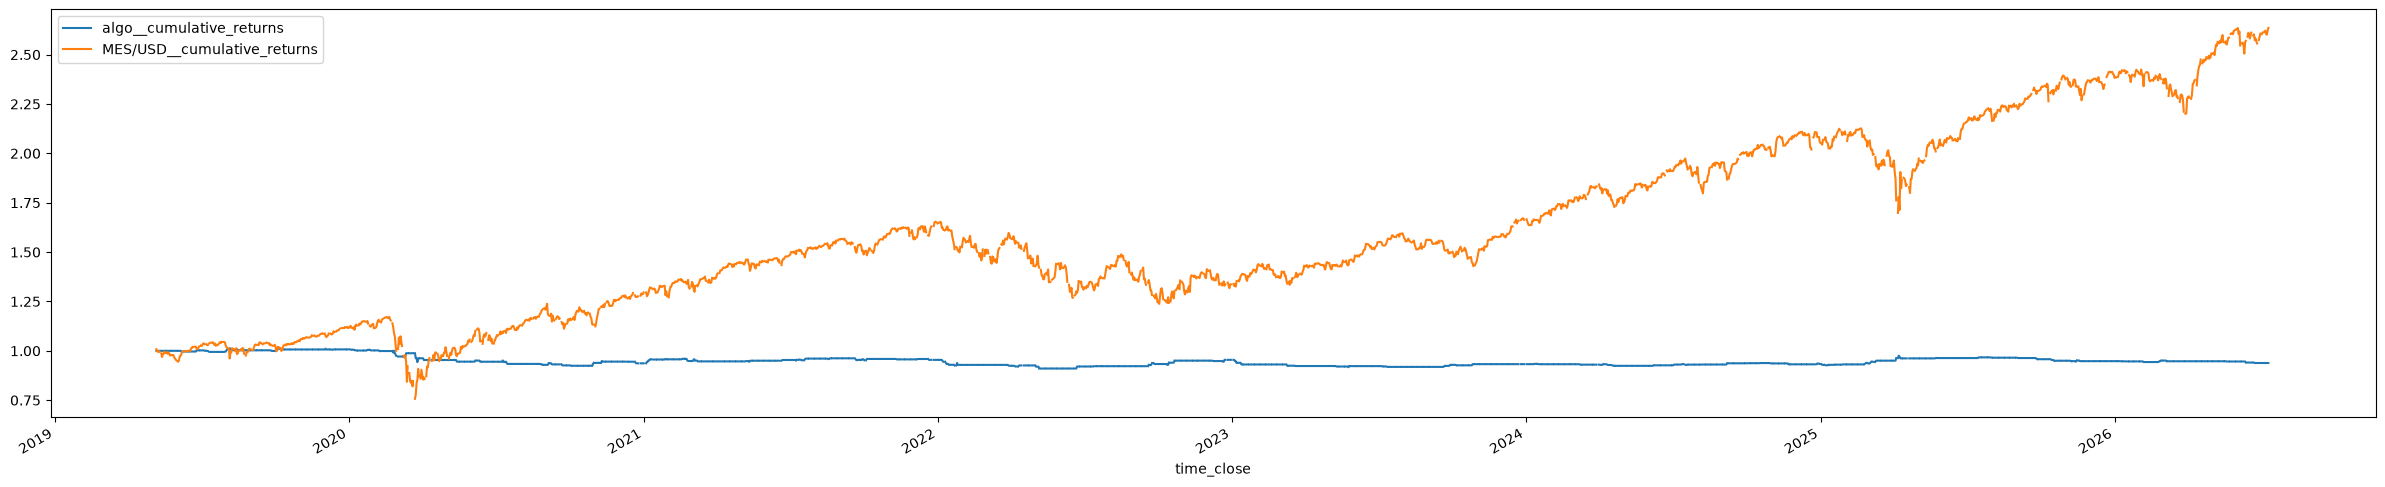

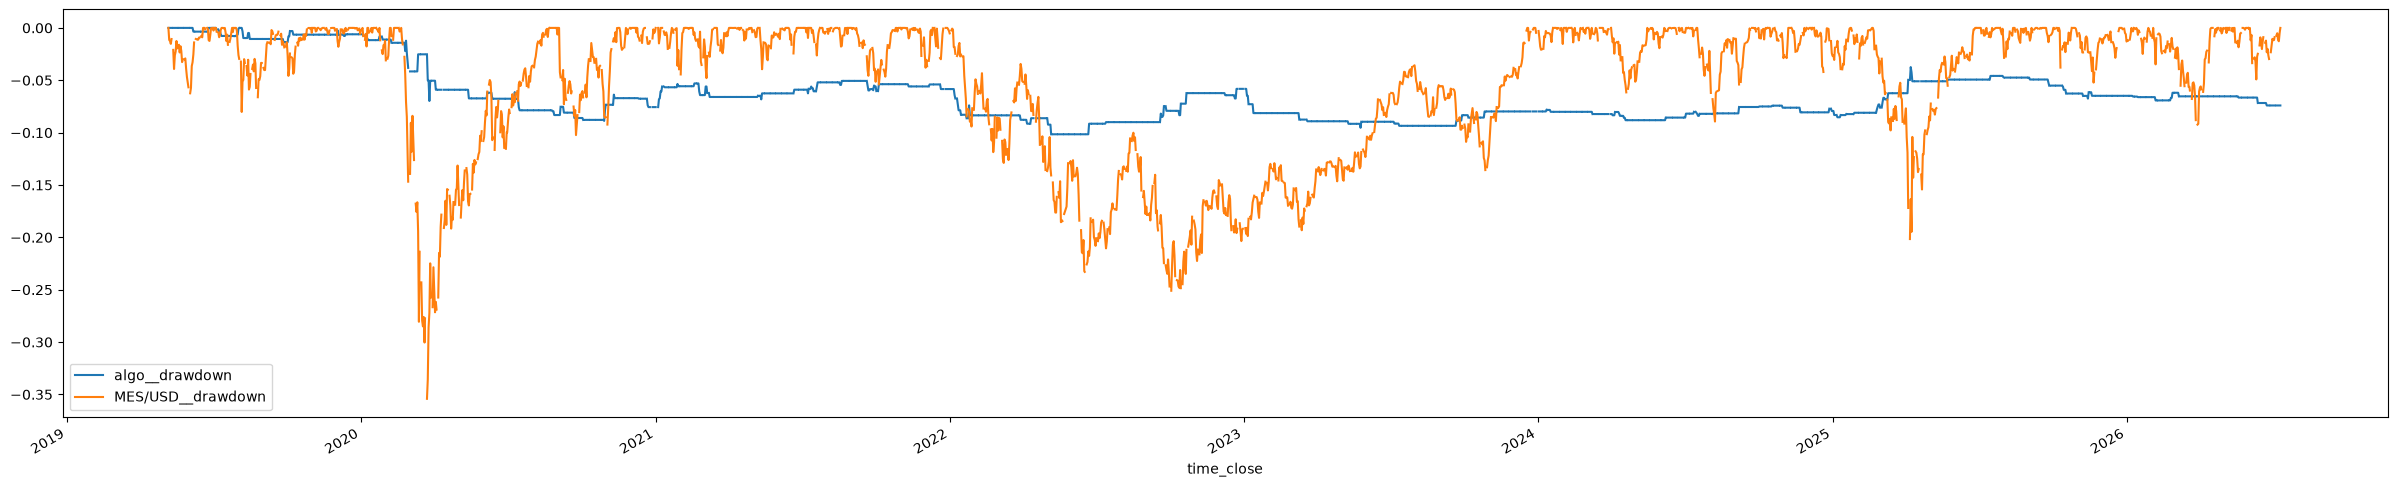

In [7]:
best_filter_label = filter_results.iloc[0]["config"]
print(f"Best config: {best_filter_label}")
best_flt_backtest, best_flt_drawdown_mw = filter_backtests[best_filter_label]

print("Account failed (drawdown breach):", best_flt_drawdown_mw.account_failed)
display(HTML(best_flt_backtest.reporter.summary_html_table(split="Y")))

if best_flt_backtest.reporter.merged is not None:
    best_flt_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__cumulative_returns",
        f"{SYMBOL}__cumulative_returns",
    ], figsize=(30, 6))

    best_flt_backtest.reporter.merged.plot(x="time_close", y=[
        "algo__drawdown",
        f"{SYMBOL}__drawdown",
    ], figsize=(30, 6))


## Findings: selectivity filters

**Every individual filter improved risk-adjusted results over the unfiltered
baseline -- the volume filter dramatically so -- but none flipped the net sign,
and the two "obvious" combinations were actively worse than doing nothing.**
(`or_minutes=15, rr=2.0` fixed throughout; baseline re-run in the same table.)

| config | net_return | sharpe | max_dd | trades | win_rate | r_mult_exp | fees |
|---|---|---|---|---|---|---|---|
| **rel_vol >= 1.5** | **-6.2%** | **-0.220** | **-10.2%** | 206 | 41.3% | +0.065 | $712 |
| atr_stop 1.0x | -22.6% | -0.265 | -37.0% | 1,813 | 50.6% | +0.007 | $4,790 |
| rel_vol >= 1.2 | -12.2% | -0.306 | -13.8% | 544 | 39.2% | +0.018 | $1,798 |
| range band 0.15-1.0 | -17.5% | -0.326 | -19.7% | 1,513 | 39.5% | +0.058 | $4,170 |
| atr_stop 0.5x | -27.3% | -0.419 | -39.2% | 1,813 | 47.5% | +0.028 | $4,179 |
| baseline | -24.6% | -0.464 | -27.1% | 1,824 | 38.9% | +0.052 | $4,819 |
| atr 1.0x + rel_vol 1.2 | -26.2% | -0.502 | -29.0% | 544 | 47.8% | **-0.029** | $1,503 |
| atr 1.0x + rel_vol 1.2 + band | -26.7% | -0.524 | -29.0% | 530 | 47.7% | -0.031 | $1,394 |

**The volume filter is the single most effective lever found in this entire
research program**: requiring opening volume >= 1.5x its trailing average cut
trades from 1,824 to 206 (~29/year), quadrupled net return (-6.2% vs -24.6%),
more than halved the Sharpe deficit (-0.220 vs -0.464), cut max drawdown to
-10.2%, and *raised* per-trade expectancy (+0.065R vs +0.052R) -- i.e. the
sessions it removed were disproportionately the bad ones, exactly what a
selectivity filter is supposed to do. Total fees over 7.2 years: **$712**
(~0.2%/year) -- costs are now a rounding error.

**The ATR-stop paradox, worth understanding**: it fixed precisely what it
aimed at -- win rate jumped to 50.6%, per-trade dollar expectancy improved --
but R-multiple expectancy collapsed to ~0. Mechanism: a 1.0x-daily-ATR stop
makes the 2R take-profit ~2 full ATRs away, which a single session almost
never reaches before the 15:55 forced flat -- so winners get time-truncated
while the (now wider) stop still takes full-size losses occasionally. **This is
also why the combinations went negative**: fewer trades (volume filter) x
truncated payoff asymmetry (ATR stop + 2R + time exit) is a structurally
incoherent trio. The untested-but-indicated fix: pair ATR stops with
`rr=None` (run to the close) instead of a fixed 2R target.

**Honest caveats**: (1) with 8 configs tested and the best cherry-picked,
`rel_vol >= 1.5`'s edge over `>= 1.2` may be partly selection luck -- the
*direction* (more selectivity -> better) is supported by the monotone pattern,
the exact threshold is not validated. (2) At 206 trades total, the per-year
cells are 10-37 trades each -- small-sample territory (per-year profit factors
swing 0.39-1.75 on noise). (3) 2020 is *still* the worst year (-7.0%) even
with the volume filter; the elevated-volume sessions it kept in 2020 were still
whipsaw sessions. (4) Still net-negative overall: -6.2% over 7.2 years
(~-0.9%/year) -- close to breakeven, not past it.

**Where this leaves ORB**: the path from -24.6% to -6.2% came entirely from
trading less, more selectively, on an unchanged entry rule -- consistent with
the first pass's diagnosis that the edge is real but diluted. The remaining
gap to profitability is small enough that the next round of candidates
(ATR stop + run-to-close exits; long-only given equity drift; the ~10:00-11:30
entry window only; volume filter recalibrated on a train split and verified
out-of-sample) each plausibly cover it -- but per this repo's standing
discipline, none of that is claimed until the engine shows it.
